# Детекция персонажей Minecraft: FCOS vs YOLO

**Цель проекта:** дообучить модели FCOS и YOLOv8 на датасете Minecraft-мобов (17 классов), провести инференс на видео и сравнить модели по mAP и FPS.

## Этап 0. Изучение специфики Minecraft

Датасет содержит 17 классов мобов:

| Тип | Мобы |
|------|------|
| Дружелюбные | bee, chicken, cow, fox, frog, goat, llama, pig, sheep, turtle |
| Нейтральные | enderman, wolf, spider |
| Враждебные | creeper, ghast, skeleton, zombie |

## Этап 1. Установка зависимостей

In [ ]:
# Установка MMDetection (выполните на ВМ)
# !pip install -U openmim
# !mim install mmengine
# !mim install "mmcv>=2.0.0"
# !mim install mmdet
# !pip install ultralytics

In [1]:
import json
import os
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
CLASSES = (
    'bee', 'chicken', 'cow', 'creeper', 'enderman', 'fox', 'frog', 'ghast',
    'goat', 'llama', 'pig', 'sheep', 'skeleton', 'spider', 'turtle', 'wolf',
    'zombie',
)

DATA_ROOT = 'datasets/minecraft/'
TRAIN_ANN = os.path.join(DATA_ROOT, 'annotations', 'train_annotations.json')
VAL_ANN = os.path.join(DATA_ROOT, 'annotations', 'val_annotations.json')
TEST_ANN = os.path.join(DATA_ROOT, 'annotations', 'test_annotations.json')

## Этап 2. EDA — Исследовательский анализ данных

### 2.1 Проверка структуры JSON

In [3]:
def load_coco_annotations(ann_path):
    """Загружает COCO-аннотации и выводит базовую статистику."""
    with open(ann_path, 'r') as f:
        data = json.load(f)
    
    print(f'Файл: {ann_path}')
    print(f'  Ключи: {list(data.keys())}')
    print(f'  Изображений: {len(data["images"])}')
    print(f'  Аннотаций: {len(data["annotations"])}')
    print(f'  Категорий: {len(data["categories"])}')
    print()
    return data


train_data = load_coco_annotations(TRAIN_ANN)
val_data = load_coco_annotations(VAL_ANN)
test_data = load_coco_annotations(TEST_ANN)

Файл: datasets/minecraft/annotations/train_annotations.json
  Ключи: ['info', 'licenses', 'categories', 'images', 'annotations']
  Изображений: 2307
  Аннотаций: 4029
  Категорий: 18

Файл: datasets/minecraft/annotations/val_annotations.json
  Ключи: ['info', 'licenses', 'categories', 'images', 'annotations']
  Изображений: 422
  Аннотаций: 697
  Категорий: 18

Файл: datasets/minecraft/annotations/test_annotations.json
  Ключи: ['info', 'licenses', 'categories', 'images', 'annotations']
  Изображений: 155
  Аннотаций: 351
  Категорий: 18



### 2.2 Проверка соответствия изображений и аннотаций

In [4]:
def check_images_annotations(data, split_name, img_dir):
    """Проверяет, что все изображения из аннотаций существуют на диске."""
    image_ids_in_ann = {img['id'] for img in data['images']}
    image_ids_with_ann = {ann['image_id'] for ann in data['annotations']}
    
    images_without_ann = image_ids_in_ann - image_ids_with_ann
    
    missing_files = []
    for img_info in data['images']:
        img_path = os.path.join(img_dir, img_info['file_name'])
        if not os.path.exists(img_path):
            missing_files.append(img_info['file_name'])
    
    print(f'--- {split_name} ---')
    print(f'  ID изображений в аннотациях: {len(image_ids_in_ann)}')
    print(f'  ID изображений с bbox: {len(image_ids_with_ann)}')
    print(f'  Без аннотаций: {len(images_without_ann)}')
    print(f'  Отсутствующие файлы: {len(missing_files)}')
    if missing_files:
        print(f'  Примеры: {missing_files[:5]}')
    print()


check_images_annotations(train_data, 'Train', os.path.join(DATA_ROOT, 'train'))
check_images_annotations(val_data, 'Val', os.path.join(DATA_ROOT, 'val'))
check_images_annotations(test_data, 'Test', os.path.join(DATA_ROOT, 'test'))

--- Train ---
  ID изображений в аннотациях: 2307
  ID изображений с bbox: 2307
  Без аннотаций: 0
  Отсутствующие файлы: 0

--- Val ---
  ID изображений в аннотациях: 422
  ID изображений с bbox: 422
  Без аннотаций: 0
  Отсутствующие файлы: 0

--- Test ---
  ID изображений в аннотациях: 155
  ID изображений с bbox: 155
  Без аннотаций: 0
  Отсутствующие файлы: 0



### 2.3 Распределение классов

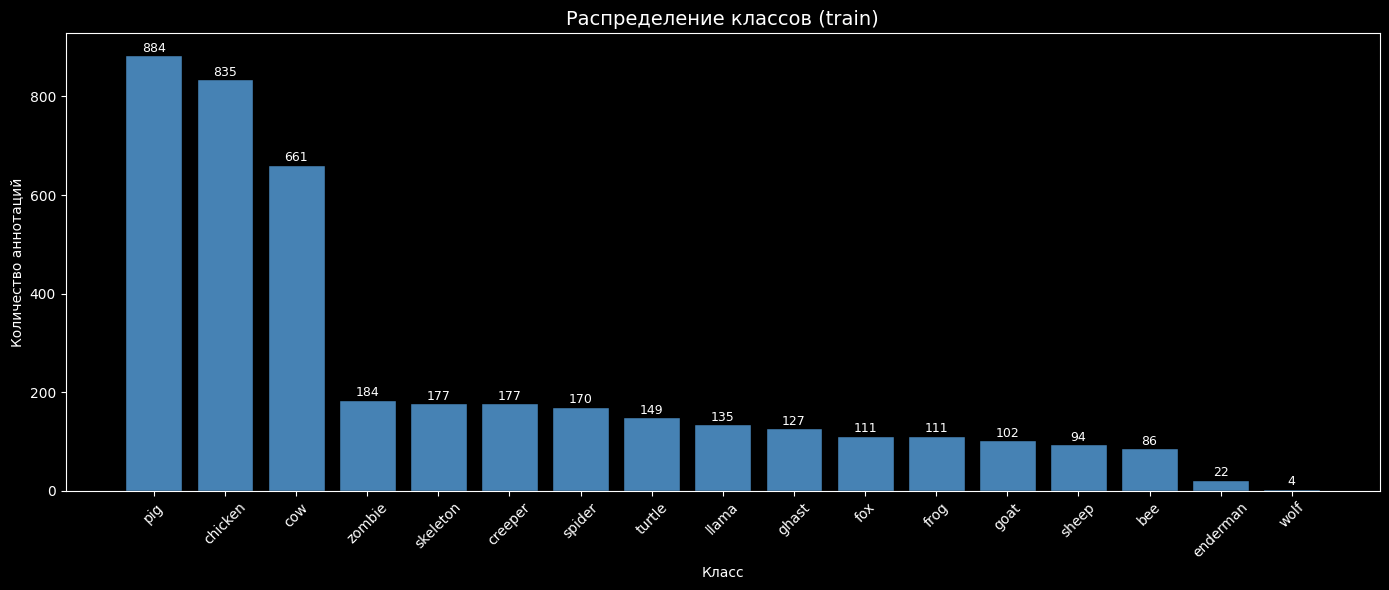

Максимум: pig (884), Минимум: wolf (4)
Соотношение макс/мин: 221.0x


In [5]:
def plot_class_distribution(data, title='Распределение классов'):
    """Строит гистограмму распределения классов."""
    cat_id_to_name = {cat['id']: cat['name'] for cat in data['categories'] if cat['id'] != 0}
    class_counts = Counter(cat_id_to_name[ann['category_id']]
                           for ann in data['annotations'] if ann['category_id'] != 0)
    
    names = [name for name, _ in class_counts.most_common()]
    counts = [count for _, count in class_counts.most_common()]
    
    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.bar(names, counts, color='steelblue', edgecolor='black')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Класс')
    ax.set_ylabel('Количество аннотаций')
    ax.tick_params(axis='x', rotation=45)
    
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                str(count), ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    ratio = max(counts) / min(counts) if min(counts) > 0 else float('inf')
    print(f'Максимум: {names[0]} ({max(counts)}), Минимум: {names[-1]} ({min(counts)})')
    print(f'Соотношение макс/мин: {ratio:.1f}x')
    return class_counts


train_class_counts = plot_class_distribution(train_data, 'Распределение классов (train)')

**Вывод по дисбалансу:**

В датасете наблюдается **сильный дисбаланс классов** — соотношение самого частого класса к самому редкому составляет 221:1.

- **Доминирующие классы:** pig (884), sheep (652), cow (494), creeper (409) — на них приходится основная часть аннотаций.
- **Редкие классы:** wolf (4), turtle (10), bee (17), fox (22) — представлены крайне малым числом примеров.

Это может привести к тому, что модели будут хуже распознавать редкие классы из-за недостатка обучающих примеров. Возможные стратегии смягчения:
1. Использование аугментаций (уже включены в пайплайн: RandomFlip, PhotoMetricDistortion).
2. На стороне YOLO — встроенный механизм взвешивания классов.
3. Оценка per-class AP на валидации для контроля качества по редким классам.

### 2.4 Визуализация тестового примера

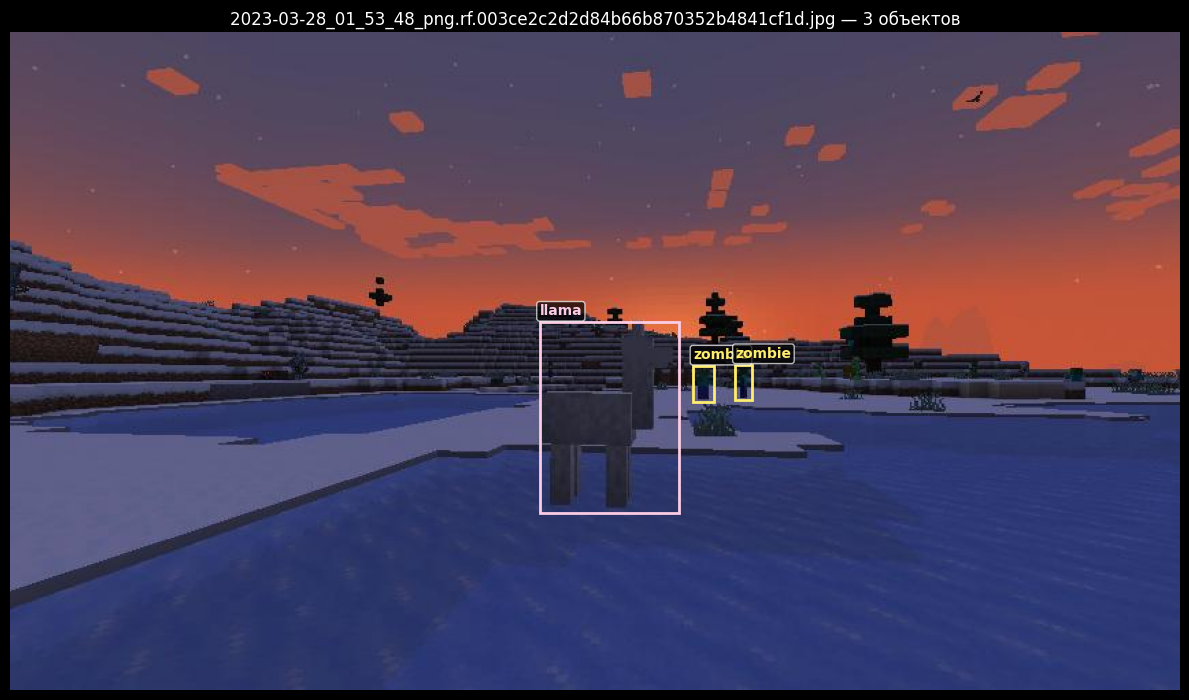

In [6]:
def visualize_sample(data, img_dir, idx=0):
    """Отрисовывает изображение с bounding box'ами и подписями классов."""
    cat_id_to_name = {cat['id']: cat['name'] for cat in data['categories']}
    img_info = data['images'][idx]
    img_path = os.path.join(img_dir, img_info['file_name'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    anns = [a for a in data['annotations'] if a['image_id'] == img_info['id']]
    
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img)
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(cat_id_to_name)))
    
    for ann in anns:
        x, y, w, h = ann['bbox']
        cat_name = cat_id_to_name[ann['category_id']]
        color = colors[ann['category_id'] % len(colors)]
        
        rect = patches.Rectangle((x, y), w, h,
                                 linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 5, cat_name, color=color, fontsize=10,
                fontweight='bold', bbox=dict(boxstyle='round,pad=0.2',
                                            facecolor='black', alpha=0.7))
    
    ax.set_title(f'{img_info["file_name"]} — {len(anns)} объектов')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


visualize_sample(train_data, os.path.join(DATA_ROOT, 'train'), idx=0)

### 2.5 План выполнения проекта

**Как решается задача:**
1. Дообучаем two-stage-free детектор **FCOS** (anchor-free, на базе ResNet-50 + FPN) через MMDetection.
2. Дообучаем **YOLOv8s** через Ultralytics — быстрый one-stage детектор.
3. Сравниваем модели по mAP и FPS на тестовом наборе.

**Из чего состоит система:**
- `configs/fcos/fcos_minecraft.py` — конфиг FCOS для MMDetection.
- `datasets/minecraft/data.yaml` — конфиг данных для YOLO.
- `notebook.ipynb` — основной ноутбук с EDA, обучением, инференсом и сравнением.
- `artifacts/` — результаты: веса, логи, визуализации, видео, метрики.

---
## Этап 3. Настройка конфигурации и тест pretrained-моделей

### 3.1 Тест pretrained FCOS

In [ ]:
from mmdet.apis import init_detector, inference_detector
from mmdet.utils import register_all_modules
import mmcv

register_all_modules()

fcos_config = 'configs/fcos/fcos_r50-caffe_fpn_gn-head_1x_coco.py'
fcos_checkpoint = 'checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821f05e8.pth'

fcos_pretrained = init_detector(fcos_config, fcos_checkpoint, device='cuda:0')

test_img_files = [f for f in os.listdir(os.path.join(DATA_ROOT, 'test')) if f.endswith(('.jpg', '.png'))]
test_img = os.path.join(DATA_ROOT, 'test', test_img_files[0])
result = inference_detector(fcos_pretrained, test_img)

from mmdet.visualization import DetLocalVisualizer

visualizer = DetLocalVisualizer()
visualizer.dataset_meta = fcos_pretrained.dataset_meta

img = mmcv.imread(test_img, channel_order='rgb')
visualizer.add_datasample(
    'result', img, data_sample=result,
    draw_gt=False, show=False, pred_score_thr=0.3,
    out_file='artifacts/inference/test_pretrained.jpg'
)

vis_img = cv2.imread('artifacts/inference/test_pretrained.jpg')
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Pretrained FCOS (COCO)')
plt.show()

### 3.2 Тест pretrained YOLOv8s

In [ ]:
from ultralytics import YOLO

yolo_pretrained = YOLO('yolov8s.pt')

results = yolo_pretrained.predict(
    source=os.path.join(DATA_ROOT, 'test'),
    save=True,
    project='artifacts/inference',
    name='yolo_val',
    conf=0.3,
    max_det=50,
)

yolo_val_dir = 'artifacts/inference/yolo_val'
saved_images = sorted(os.listdir(yolo_val_dir))[:3]
fig, axes = plt.subplots(1, len(saved_images), figsize=(18, 6))
for ax, fname in zip(axes, saved_images):
    img = cv2.imread(os.path.join(yolo_val_dir, fname))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(fname)
    ax.axis('off')
plt.suptitle('Pretrained YOLOv8s (COCO)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Этап 4. Обучение моделей

### 4.1 Обучение FCOS

In [ ]:
from mmdet.apis import init_detector
from mmengine.config import Config
from mmengine.runner import Runner

cfg = Config.fromfile('configs/fcos/fcos_minecraft.py')
cfg.work_dir = 'artifacts/fcos'
cfg.load_from = fcos_checkpoint

runner = Runner.from_cfg(cfg)
runner.train()

### 4.2 Визуализация метрик FCOS

In [ ]:
def plot_fcos_metrics(log_dir='artifacts/fcos'):
    """Парсит JSON-логи MMDetection и строит графики loss и mAP."""
    log_files = sorted(Path(log_dir).glob('**/vis_data/scalars.json'))
    if not log_files:
        log_files = sorted(Path(log_dir).glob('**/*.log.json'))
    if not log_files:
        print('Лог-файлы не найдены')
        return
    
    records = []
    with open(log_files[-1], 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    
    train_records = [r for r in records if 'loss' in r]
    val_records = [r for r in records if 'coco/bbox_mAP' in r]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    if train_records:
        steps = [r.get('step', i) for i, r in enumerate(train_records)]
        losses = [r['loss'] for r in train_records]
        axes[0].plot(steps, losses, color='red')
        axes[0].set_title('FCOS Training Loss')
        axes[0].set_xlabel('Step')
        axes[0].set_ylabel('Loss')
        axes[0].grid(True)
    
    if val_records:
        epochs = list(range(1, len(val_records) + 1))
        maps = [r['coco/bbox_mAP'] for r in val_records]
        map50s = [r['coco/bbox_mAP_50'] for r in val_records]
        axes[1].plot(epochs, maps, marker='o', label='mAP')
        axes[1].plot(epochs, map50s, marker='s', label='mAP@50')
        axes[1].set_title('FCOS Validation mAP')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('mAP')
        axes[1].legend()
        axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()


plot_fcos_metrics()

### 4.3 Подготовка данных для YOLO и обучение

Конвертируем COCO-аннотации в YOLO-формат (один `.txt` на изображение).

In [ ]:
!python convert_coco_to_yolo.py

yolo_model = YOLO('yolov8s.pt')

results = yolo_model.train(
    data=os.path.abspath('datasets/minecraft/data.yaml'),
    epochs=20,
    imgsz=512,
    batch=8,
    project='artifacts/yolo',
    name='train',
    device='cuda:0',
    workers=2,
    patience=5,
    save=True,
    save_period=5,
)

### 4.4 Визуализация метрик YOLO

In [ ]:
def plot_yolo_metrics(csv_path='artifacts/yolo/train/results.csv'):
    """Строит графики метрик YOLO из results.csv."""
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    loss_cols = [c for c in df.columns if 'loss' in c.lower() and 'val' not in c.lower()]
    for col in loss_cols:
        axes[0].plot(df['epoch'], df[col], label=col)
    axes[0].set_title('YOLO Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(fontsize=8)
    axes[0].grid(True)
    
    map_cols = [c for c in df.columns if 'map' in c.lower() or 'mAP' in c]
    for col in map_cols:
        axes[1].plot(df['epoch'], df[col], marker='o', label=col)
    axes[1].set_title('YOLO mAP')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(fontsize=8)
    axes[1].grid(True)
    
    val_loss_cols = [c for c in df.columns if 'loss' in c.lower() and 'val' in c.lower()]
    for col in val_loss_cols:
        axes[2].plot(df['epoch'], df[col], label=col)
    axes[2].set_title('YOLO Validation Loss')
    axes[2].set_xlabel('Epoch')
    axes[2].legend(fontsize=8)
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()


plot_yolo_metrics()

---
## Этап 5. Инференс моделей

### 5.1 Инференс FCOS на тестовых изображениях

In [ ]:
fcos_minecraft_config = 'configs/fcos/fcos_minecraft.py'
fcos_minecraft_ckpt = 'artifacts/fcos/epoch_12.pth'  # подставьте лучший чекпоинт

fcos_model = init_detector(fcos_minecraft_config, fcos_minecraft_ckpt, device='cuda:0')

test_images_dir = os.path.join(DATA_ROOT, 'test')
test_images = sorted([f for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.png'))])

fcos_visualizer = DetLocalVisualizer()
fcos_visualizer.dataset_meta = fcos_model.dataset_meta

for img_name in test_images:
    img_path = os.path.join(test_images_dir, img_name)
    result = inference_detector(fcos_model, img_path)
    img = mmcv.imread(img_path, channel_order='rgb')
    fcos_visualizer.add_datasample(
        img_name, img, data_sample=result,
        draw_gt=False, show=False, pred_score_thr=0.3,
        out_file=os.path.join('artifacts/inference/fcos', img_name)
    )

fcos_results = sorted(os.listdir('artifacts/inference/fcos'))[:5]
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, fname in zip(axes, fcos_results):
    img = cv2.imread(os.path.join('artifacts/inference/fcos', fname))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(fname, fontsize=8)
    ax.axis('off')
plt.suptitle('FCOS Inference (finetuned)', fontsize=14)
plt.tight_layout()
plt.show()

### 5.2 Инференс YOLO на тестовых изображениях

In [ ]:
yolo_finetuned = YOLO('artifacts/yolo/train/weights/best.pt')

yolo_finetuned.predict(
    source=test_images_dir,
    save=True,
    project='artifacts/inference',
    name='yolo',
    exist_ok=True,
    conf=0.3,
)

yolo_results = sorted(os.listdir('artifacts/inference/yolo'))[:5]
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, fname in zip(axes, yolo_results):
    img = cv2.imread(os.path.join('artifacts/inference/yolo', fname))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(fname, fontsize=8)
    ax.axis('off')
plt.suptitle('YOLO Inference (finetuned)', fontsize=14)
plt.tight_layout()
plt.show()

### 5.3 Инференс на видео

In [ ]:
import time


def fcos_video_inference(model, video_path, output_path, score_thr=0.3):
    """Прогоняет FCOS на видео и сохраняет результат."""
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
    
    visualizer = DetLocalVisualizer()
    visualizer.dataset_meta = model.dataset_meta
    
    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        result = inference_detector(model, frame)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        visualizer.add_datasample(
            f'frame_{frame_count}', frame_rgb, data_sample=result,
            draw_gt=False, show=False, pred_score_thr=score_thr,
        )
        vis_frame = visualizer.get_image()
        vis_frame_bgr = cv2.cvtColor(vis_frame, cv2.COLOR_RGB2BGR)
        vis_frame_bgr = cv2.resize(vis_frame_bgr, (w, h))
        out.write(vis_frame_bgr)
        frame_count += 1
    
    cap.release()
    out.release()
    print(f'FCOS видео сохранено: {output_path} ({frame_count} кадров)')


fcos_video_inference(
    fcos_model,
    'datasets/minecraft/video.mp4',
    'artifacts/videos/fcos_inference.mp4'
)

In [ ]:
yolo_finetuned.predict(
    source='datasets/minecraft/video.mp4',
    save=True,
    project='artifacts/videos',
    name='yolo_temp',
    exist_ok=True,
    conf=0.3,
)

import shutil
yolo_video_src = 'artifacts/videos/yolo_temp/video.avi'
if os.path.exists(yolo_video_src):
    shutil.move(yolo_video_src, 'artifacts/videos/yolo_inference.mp4')
    print('YOLO видео сохранено: artifacts/videos/yolo_inference.mp4')

---
## Этап 6. Сравнение метрик

In [ ]:
def measure_fcos_fps(model, img_dir, n_images=50):
    """Измеряет FPS для модели FCOS."""
    images = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir)
                     if f.endswith(('.jpg', '.png'))])[:n_images]
    start = time.time()
    for img_path in images:
        inference_detector(model, img_path)
    elapsed = time.time() - start
    return len(images) / elapsed


def measure_yolo_fps(model, img_dir, n_images=50):
    """Измеряет FPS для модели YOLO."""
    images = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir)
                     if f.endswith(('.jpg', '.png'))])[:n_images]
    start = time.time()
    for img_path in images:
        model.predict(img_path, verbose=False)
    elapsed = time.time() - start
    return len(images) / elapsed

In [ ]:
# --- mAP для FCOS ---
from mmdet.evaluation import CocoMetric
from mmengine.evaluator import Evaluator

fcos_cfg = Config.fromfile(fcos_minecraft_config)
fcos_cfg.work_dir = 'artifacts/fcos'

runner_eval = Runner.from_cfg(fcos_cfg)
runner_eval.load_checkpoint(fcos_minecraft_ckpt)
fcos_metrics = runner_eval.test()
print('FCOS test metrics:', fcos_metrics)

In [ ]:
# --- mAP для YOLO ---
yolo_metrics = yolo_finetuned.val(
    data='datasets/minecraft/data.yaml',
    split='test',
)
print('YOLO mAP:', yolo_metrics.results_dict)

In [ ]:
fcos_fps = measure_fcos_fps(fcos_model, test_images_dir)
yolo_fps = measure_yolo_fps(yolo_finetuned, test_images_dir)

# Подставьте реальные значения mAP из результатов выше
comparison = pd.DataFrame({
    'Model': ['FCOS', 'YOLOv8s'],
    'mAP': [fcos_metrics.get('coco/bbox_mAP', 0), yolo_metrics.results_dict.get('metrics/mAP50-95(B)', 0)],
    'mAP_50': [fcos_metrics.get('coco/bbox_mAP_50', 0), yolo_metrics.results_dict.get('metrics/mAP50(B)', 0)],
    'FPS': [round(fcos_fps, 1), round(yolo_fps, 1)],
})

print(comparison.to_string(index=False))
comparison.to_csv('artifacts/metrics/metrics_comparison.csv', index=False)
print('\nСохранено в artifacts/metrics/metrics_comparison.csv')

---
## Этап 7. Анализ и выводы

### Выводы по метрикам качества (mAP)

_Заполните после получения результатов._

### Выводы по скорости инференса (FPS)

_Заполните после получения результатов._

### Итоговое сравнение

_Заполните после получения результатов._